In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler

This dataset contains information such as age, education, occupation, working hours, and income. The aim of the dataset is to predict whether a person's annual income is above or below $50,000.

In [2]:
df = pd.read_csv("/Users/micheal/Downloads/adult_dataset.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.shape

(32561, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [5]:
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object

In [6]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

## Handle Missing Values

using dropna() to remove records with missing values. 
#removed rows with missing value

In [7]:
df_drop = df.copy()

print("Before:", df_drop.shape)

df_drop = df_drop.dropna()

print("After:", df_drop.shape)

Before: (32561, 15)
After: (30162, 15)


using mode imputation because the missing values occurred in categorical variables. 
mode imputation forwhere missing values were replaced with the most common value in each column.

In [8]:
df_fill = df.copy()

df_fill["workclass"] = df_fill["workclass"].fillna(df_fill["workclass"].mode()[0])
df_fill["occupation"] = df_fill["occupation"].fillna(df_fill["occupation"].mode()[0])
df_fill["native_country"] = df_fill["native_country"].fillna(df_fill["native_country"].mode()[0])

df_fill.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

## Label Encoding for the Income column.

In [9]:
df_fill["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [10]:
df_fill["income"].value_counts()

label_encoder = LabelEncoder()

df_fill["income"] = label_encoder.fit_transform(df_fill["income"])

print(df_fill["income"].value_counts())
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

income
0    24720
1     7841
Name: count, dtype: int64
{'<=50K': np.int64(0), '>50K': np.int64(1)}


##encoding(using two methods)

I used Label Encoding because the income variable has only two categories <=50K and >50K.this converts the income column from text to numbers.

In [11]:
df_fill["sex"].value_counts()

sex
Male      21790
Female    10771
Name: count, dtype: int64

In [12]:
print(df_fill.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [13]:
df_fill = pd.get_dummies(df_fill, columns=["sex"], drop_first=True)

print(df_fill.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income', 'sex_Male']


In [14]:
df_fill["sex_Male"].value_counts()

sex_Male
True     21790
False    10771
Name: count, dtype: int64

##One-Hot Encoding for the Sex column

i used one hot encoding because sex is a nominal data where there's no inherent order.
The original sex column was converted into a new binary column called sex_Male, where:
1 represents Male
0 represents Female


In [15]:
df_fill.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456,0.240810
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429,0.427581
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [16]:
numerical_columns = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

## Feature scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

##The numerical variables had different ranges.
For example, Age has much smaller values than fnlwgt.

This transformed the numerical features so they have a mean close to 0 and a standard deviation close to 1.

In [18]:
bins = [0, 30, 50, 100]
labels = ["Young Adult", "Adult", "Senior"]

df_fill["Age_Group"] = pd.cut(
    df_fill["age"],
    bins=bins,
    labels=labels
)

df_fill[["age", "Age_Group"]].head()

,age,Age_Group
0,39,Adult
1,50,Adult
2,38,Adult
3,53,Senior
4,28,Young Adult


In [19]:
df_scaled = df_fill.copy()

df_scaled[numerical_columns] = scaler.fit_transform(df_scaled[numerical_columns])

In [20]:
df_scaled[numerical_columns].head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


In [21]:
df_scaled.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income
count,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04,32561.000000
mean,-2.662271e-17,-9.732565e-17,1.479525e-16,5.237255e-18,-4.364379e-17,-2.574984e-17,0.240810
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,0.427581
min,-1.582206e+00,-1.681631e+00,-3.529656e+00,-1.459205e-01,-2.166595e-01,-3.194030e+00,0.000000
25%,-7.757679e-01,-6.816910e-01,-4.200596e-01,-1.459205e-01,-2.166595e-01,-3.542945e-02,0.000000
50%,-1.159546e-01,-1.082193e-01,-3.136003e-02,-1.459205e-01,-2.166595e-01,-3.542945e-02,0.000000
75%,6.904838e-01,4.478765e-01,7.460392e-01,-1.459205e-01,-2.166595e-01,3.695194e-01,0.000000
max,3.769612e+00,1.226856e+01,2.300838e+00,1.339458e+01,1.059351e+01,4.742967e+00,1.000000


I used standard scaler because the numerical features were measured on different scales.The numerical variables were transformed to have similar scales.

## Detect Outliers Using the IQR Method

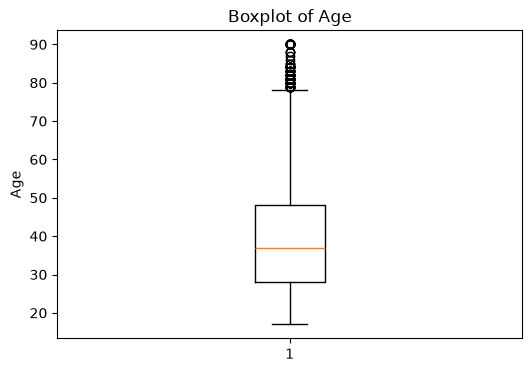

In [22]:
plt.figure(figsize=(6,4))
plt.boxplot(df_fill["age"])
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

In [23]:
Q1 = df_fill["age"].quantile(0.25)
Q3 = df_fill["age"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 28.0
Q3: 48.0
IQR: 20.0


In [24]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -2.0
Upper Limit: 78.0


In [25]:
outliers = df_fill[
    (df_fill["age"] < lower_limit) |
    (df_fill["age"] > upper_limit)
]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 143


In [26]:
outliers.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_Male,Age_Group
74,79,Private,124744,Some-college,10,Married-civ-spouse,Prof-specialty,Other-relative,White,0,0,20,United-States,0,True,Senior
222,90,Private,51744,HS-grad,9,Never-married,Other-service,Not-in-family,Black,0,2206,40,United-States,0,True,Senior
430,80,Private,107762,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,0,0,24,United-States,0,True,Senior
918,81,Self-emp-not-inc,136063,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,0,0,30,United-States,0,True,Senior
1040,90,Private,137018,HS-grad,9,Never-married,Other-service,Not-in-family,White,0,0,40,United-States,0,False,Senior


## Remove outliers

In [27]:
df_no_outliers = df_fill[
    (df_fill["age"] >= lower_limit) &
    (df_fill["age"] <= upper_limit)
]

print("Shape before:", df_fill.shape)
print("Shape after:", df_no_outliers.shape)

Shape before: (32561, 16)
Shape after: (32418, 16)


## Creating new feature engineering

In [28]:
bins = [0, 30, 50, 100]
labels = ["Young Adult", "Adult", "Senior"]

df_no_outliers["Age_Group"] = pd.cut(
    df_no_outliers["age"],
    bins=bins,
    labels=labels
)

df_no_outliers.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_Male,Age_Group
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,2174,0,40,United-States,0,True,Adult
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,13,United-States,0,True,Adult
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,40,United-States,0,True,Adult
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,40,United-States,0,True,Senior
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,40,Cuba,0,False,Young Adult


In [29]:
df_no_outliers["Age_Group"].value_counts()

Age_Group
Adult          15529
Young Adult    10572
Senior          6317
Name: count, dtype: int64

In [30]:
#Before
df_no_outliers["age"].head()

0    39
1    50
2    38
3    53
4    28
Name: age, dtype: int64

In [31]:
#After
df_no_outliers[["age", "Age_Group"]].head()

,age,Age_Group
0,39,Adult
1,50,Adult
2,38,Adult
3,53,Senior
4,28,Young Adult


## Challenges faced

1.one was deciding how best to handle missing values.I had to choose between removing rows with missing data and filling them with the most common value
i also had to decide what method of encoding to use for categorical variables.

##How did different imputation or encoding methods affect your data? Do you foresee any potential issues for a machine learning model?

2.Dropping missing values reduced the size of the dataset, while mode imputation kept all the records by replacing missing values with the most common category.

##Which preprocessing step do you think was the most impactful for your chosen dataset and why?
handling missing values was the most important step because missing data can affect the accuracy of analysis and machine learning models.


##When would you choose to drop rows or columns with missing values instead of imputing them?

I would remove rows or columns when only a small portion of the data is missing and removing them will not significantly reduce the dataset.

##Can you think of a scenario where not handling outliers would severely impact a model?

For example, in predicting salaries or house prices, a few extremely large values could distort the model and reduce its accuracy. Removing or treating outliers helps the model learn from the majority of the data instead of being influenced by extreme observations.